# 06 — Evaluate GaitTR Fixed Recommended Version

এই notebook আপনার fixed training checkpoint evaluate করবে।

Default checkpoint:

```text
/media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_fixed_last.pth
```

এই notebook করবে:

1. fixed checkpoint load
2. gallery/probe CSV dtype-safe ভাবে read
3. gallery embeddings extract
4. NM/BG/CL probe embeddings extract
5. identical-view বাদ দিয়ে Rank-1 accuracy calculate
6. per-view result save
7. embedding collapse diagnostic save

Expected input files:

```text
data/splits/gallery_LT.csv
data/splits/probe_LT_nm.csv
data/splits/probe_LT_bg.csv
data/splits/probe_LT_cl.csv
checkpoints/gaittr_LT_fixed_last.pth
```

Main output files:

```text
results/rank1_LT_summary.csv
results/rank1_LT_per_view.csv
results/rank1_LT_all_probe_results.csv
```

Tagged copies will also be saved using checkpoint name, for example:

```text
results/rank1_LT_gaittr_LT_fixed_last_summary.csv
```

In [1]:
# ============================================================
# CELL 1 — Imports, config, paths
# ============================================================

from pathlib import Path
import json
import time
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")
SPLIT_NAME = "LT"

SPLIT_DIR = EXP_DIR / "data" / "splits"
CHECKPOINT_DIR = EXP_DIR / "checkpoints"
RESULT_DIR = EXP_DIR / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# IMPORTANT:
# Evaluate your fixed recommended training checkpoint.
# First evaluate last checkpoint.
# Later you can change this to gaittr_LT_fixed_best_loss.pth.
CHECKPOINT_PATH = CHECKPOINT_DIR / "gaittr_LT_fixed_last.pth"

# Alternative:
# CHECKPOINT_PATH = CHECKPOINT_DIR / "gaittr_LT_fixed_best_loss.pth"

# Evaluation mode:
# "sliding" = split full sequence into 60-frame clips, average embeddings.
# "full"    = use whole skeleton sequence directly.
#
# Recommended first run: "sliding"
# because training used 60-frame clips.
EVAL_MODE = "sliding"
SEQ_LEN = 60
STRIDE = 30
BATCH_CLIPS = 64

EXCLUDE_IDENTICAL_VIEW = True
SAVE_EMBEDDINGS = True

# Diagnostics
PAIRWISE_DIAG_N = 300

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("GaitTR Fixed Evaluation Notebook")
print("=" * 80)
print("EXP_DIR        :", EXP_DIR)
print("SPLIT_NAME     :", SPLIT_NAME)
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("EVAL_MODE      :", EVAL_MODE)
print("Device         :", device)
if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
print("=" * 80)

assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"

GaitTR Fixed Evaluation Notebook
EXP_DIR        : /media/wadud/DriveUbuntu/GaitRecognition 2.0
SPLIT_NAME     : LT
CHECKPOINT_PATH: /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_fixed_last.pth
EVAL_MODE      : sliding
Device         : cuda
GPU            : NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
# ============================================================
# CELL 2 — Feature builder
# ============================================================

COCO_PARENTS = np.array([
    0,   # 0 nose
    0,   # 1 left_eye      <- nose
    0,   # 2 right_eye     <- nose
    1,   # 3 left_ear      <- left_eye
    2,   # 4 right_ear     <- right_eye
    0,   # 5 left_shoulder <- nose
    0,   # 6 right_shoulder<- nose
    5,   # 7 left_elbow    <- left_shoulder
    6,   # 8 right_elbow   <- right_shoulder
    7,   # 9 left_wrist    <- left_elbow
    8,   # 10 right_wrist  <- right_elbow
    5,   # 11 left_hip     <- left_shoulder
    6,   # 12 right_hip    <- right_shoulder
    11,  # 13 left_knee    <- left_hip
    12,  # 14 right_knee   <- right_hip
    13,  # 15 left_ankle   <- left_knee
    14,  # 16 right_ankle  <- right_knee
], dtype=np.int64)

def crop_or_pad_sequence(X, seq_len=60, random_crop=False):
    T = X.shape[0]

    if T == seq_len:
        return X

    if T > seq_len:
        if random_crop:
            start = np.random.randint(0, T - seq_len + 1)
        else:
            start = max(0, (T - seq_len) // 2)
        return X[start:start + seq_len]

    pad_len = seq_len - T
    pad = np.repeat(X[-1:], pad_len, axis=0)
    return np.concatenate([X, pad], axis=0)

def make_sliding_clips(X, clip_len=60, stride=30):
    T = X.shape[0]

    if T <= clip_len:
        return [crop_or_pad_sequence(X, clip_len, random_crop=False)]

    clips = []
    for start in range(0, T - clip_len + 1, stride):
        clips.append(X[start:start + clip_len])

    # Make sure tail information is not completely missed.
    last_start = T - clip_len
    if clips and last_start > 0:
        tail_clip = X[last_start:last_start + clip_len]
        if not np.array_equal(clips[-1], tail_clip):
            clips.append(tail_clip)

    if not clips:
        clips.append(crop_or_pad_sequence(X, clip_len, random_crop=False))

    return clips

def build_gaittr_features(X):
    X = X.astype(np.float32)

    assert X.ndim == 3, f"Expected (T,17,2), got {X.shape}"
    assert X.shape[1] == 17, f"Expected 17 joints, got {X.shape[1]}"
    assert X.shape[2] == 2, f"Expected x,y coordinates, got {X.shape[2]}"

    joint = X.copy()

    nose = X[:, 0:1, :]
    joint_rel = X - nose

    v1 = np.zeros_like(X)
    v1[:-1] = X[1:] - X[:-1]

    v2 = np.zeros_like(X)
    v2[:-2] = X[2:] - X[:-2]

    bone = X - X[:, COCO_PARENTS, :]

    feat = np.concatenate([joint, joint_rel, v1, v2, bone], axis=-1)
    feat = feat.transpose(2, 0, 1).astype(np.float32)

    return feat

In [3]:
# ============================================================
# CELL 3 — GaitTR model definition
# Must match 05_train_gaittr_fixed_recommended.ipynb
# ============================================================

class TCN(nn.Module):
    def __init__(self, in_channels, out_channels, temporal_kernel=9, dropout=0.1):
        super().__init__()
        pad = temporal_kernel // 2

        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=(temporal_kernel, 1),
                padding=(pad, 0),
                bias=False
            ),
            nn.Dropout(dropout),
            nn.Mish(),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.net(x)


class SpatialTransformer(nn.Module):
    def __init__(self, channels, num_heads=8, dropout=0.1):
        super().__init__()

        assert channels % num_heads == 0, (
            f"channels={channels} must be divisible by num_heads={num_heads}"
        )

        self.norm = nn.LayerNorm(channels)

        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.proj = nn.Linear(channels, channels)
        self.act = nn.Mish()
        self.bn = nn.BatchNorm2d(channels)

    def forward(self, x):
        # x: B x C x T x V
        B, C, T, V = x.shape

        # B x C x T x V -> B x T x V x C -> (B*T) x V x C
        tokens = x.permute(0, 2, 3, 1).contiguous()
        tokens = tokens.view(B * T, V, C)

        tokens = self.norm(tokens)
        out, _ = self.attn(tokens, tokens, tokens, need_weights=False)
        out = self.proj(out)

        # (B*T) x V x C -> B x C x T x V
        out = out.view(B, T, V, C)
        out = out.permute(0, 3, 1, 2).contiguous()

        out = self.act(out)
        out = self.bn(out)

        return out


class TCNSTBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        num_heads=8,
        temporal_kernel=9,
        dropout=0.1,
    ):
        super().__init__()

        self.tcn = TCN(
            in_channels=in_channels,
            out_channels=out_channels,
            temporal_kernel=temporal_kernel,
            dropout=dropout,
        )

        self.st = SpatialTransformer(
            channels=out_channels,
            num_heads=num_heads,
            dropout=dropout,
        )

        if in_channels == out_channels:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.Mish(),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = self.residual(x)
        out = self.tcn(x)
        out = self.st(out)
        return out + identity


class GaitTR(nn.Module):
    def __init__(
        self,
        in_channels=10,
        embedding_dim=128,
        channels=(64, 64, 128, 256),
        num_heads=8,
        temporal_kernel=9,
        dropout=0.1,
    ):
        super().__init__()

        self.data_bn = nn.BatchNorm2d(in_channels)

        blocks = []
        prev_channels = in_channels

        for out_channels in channels:
            blocks.append(
                TCNSTBlock(
                    in_channels=prev_channels,
                    out_channels=out_channels,
                    num_heads=num_heads,
                    temporal_kernel=temporal_kernel,
                    dropout=dropout,
                )
            )
            prev_channels = out_channels

        self.blocks = nn.Sequential(*blocks)
        self.fc = nn.Linear(channels[-1], embedding_dim, bias=False)

    def forward(self, x):
        x = self.data_bn(x)
        x = self.blocks(x)
        x = x.mean(dim=(2, 3))
        emb = self.fc(x)
        emb = F.normalize(emb, p=2, dim=1)
        return emb

In [4]:
# ============================================================
# CELL 4 — Load checkpoint and model
# ============================================================

def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

ckpt = safe_torch_load(CHECKPOINT_PATH, map_location=device)
config = ckpt.get("config", {})

in_channels = int(config.get("in_channels", 10))
embedding_dim = int(config.get("embedding_dim", 128))
channels = tuple(config.get("channels", [64, 64, 128, 256]))
num_heads = int(config.get("num_heads", 8))
temporal_kernel = int(config.get("temporal_kernel", 9))
dropout = float(config.get("dropout", 0.1))

model = GaitTR(
    in_channels=in_channels,
    embedding_dim=embedding_dim,
    channels=channels,
    num_heads=num_heads,
    temporal_kernel=temporal_kernel,
    dropout=dropout,
).to(device)

model.load_state_dict(ckpt["model"], strict=True)
model.eval()

RUN_TAG = CHECKPOINT_PATH.stem

print("=" * 80)
print("Checkpoint loaded")
print("=" * 80)
print("checkpoint :", CHECKPOINT_PATH)
print("run_tag    :", RUN_TAG)
print("step       :", ckpt.get("step", "unknown"))
print("channels   :", channels)
print("embed dim  :", embedding_dim)
print("num_heads  :", num_heads)
print("kernel     :", temporal_kernel)
print("dropout    :", dropout)
print("=" * 80)

# Model forward sanity check
dummy = torch.randn(2, 10, 60, 17).to(device)
with torch.no_grad():
    test_emb = model(dummy)
print("Test embedding shape:", test_emb.shape)
assert test_emb.shape == (2, embedding_dim)
del dummy, test_emb
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Checkpoint loaded
checkpoint : /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_fixed_last.pth
run_tag    : gaittr_LT_fixed_last
step       : 30000
channels   : (64, 64, 128, 256)
embed dim  : 128
num_heads  : 8
kernel     : 9
dropout    : 0.1
Test embedding shape: torch.Size([2, 128])


In [5]:
# ============================================================
# CELL 5 — Load gallery/probe split CSVs safely
# ============================================================

csv_dtype = {
    "pose_path": str,
    "subject": str,
    "condition": str,
    "seq": str,
    "view": str,
}

gallery_csv = SPLIT_DIR / f"gallery_{SPLIT_NAME}.csv"
probe_nm_csv = SPLIT_DIR / f"probe_{SPLIT_NAME}_nm.csv"
probe_bg_csv = SPLIT_DIR / f"probe_{SPLIT_NAME}_bg.csv"
probe_cl_csv = SPLIT_DIR / f"probe_{SPLIT_NAME}_cl.csv"

for p in [gallery_csv, probe_nm_csv, probe_bg_csv, probe_cl_csv]:
    assert p.exists(), f"Missing split file: {p}"

df_gallery = pd.read_csv(gallery_csv, dtype=csv_dtype)
df_probe_nm = pd.read_csv(probe_nm_csv, dtype=csv_dtype)
df_probe_bg = pd.read_csv(probe_bg_csv, dtype=csv_dtype)
df_probe_cl = pd.read_csv(probe_cl_csv, dtype=csv_dtype)

def check_paths_exist(df, name):
    missing = [p for p in df["pose_path"].tolist() if not Path(p).exists()]
    print(f"{name}: rows={len(df)}, subjects={df['subject'].nunique()}, missing_paths={len(missing)}")
    if missing:
        print("First missing:", missing[0])
        raise FileNotFoundError(f"{name} has missing pose paths.")

check_paths_exist(df_gallery, "gallery")
check_paths_exist(df_probe_nm, "probe_nm")
check_paths_exist(df_probe_bg, "probe_bg")
check_paths_exist(df_probe_cl, "probe_cl")

print()
print("Gallery expected LT: 2200")
print("Probe expected LT  : 1100 each")
print()
display(df_gallery.head())

gallery: rows=2200, subjects=50, missing_paths=0
probe_nm: rows=1100, subjects=50, missing_paths=0
probe_bg: rows=1100, subjects=50, missing_paths=0
probe_cl: rows=1100, subjects=50, missing_paths=0

Gallery expected LT: 2200
Probe expected LT  : 1100 each



,pose_path,subject,condition,seq,view
0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,000
1,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,018
2,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,036
3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,054
4,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,072


In [6]:
# ============================================================
# CELL 6 — Embedding extraction
# ============================================================

@torch.no_grad()
def extract_video_embedding(pose_path):
    data = np.load(pose_path)
    X = data["keypoints_norm_filled"].astype(np.float32)

    if EVAL_MODE == "full":
        feat = build_gaittr_features(X)
        x = torch.from_numpy(feat).unsqueeze(0).float().to(device)
        emb = model(x).squeeze(0).cpu()
        emb = F.normalize(emb, p=2, dim=0)
        return emb

    if EVAL_MODE == "sliding":
        clips = make_sliding_clips(X, clip_len=SEQ_LEN, stride=STRIDE)
        feats = np.stack([build_gaittr_features(c) for c in clips], axis=0)

        embs = []
        for start in range(0, len(feats), BATCH_CLIPS):
            batch = torch.from_numpy(feats[start:start + BATCH_CLIPS]).float().to(device)
            emb = model(batch)
            embs.append(emb.cpu())

        embs = torch.cat(embs, dim=0)
        final_emb = embs.mean(dim=0)
        final_emb = F.normalize(final_emb, p=2, dim=0)
        return final_emb

    raise ValueError(f"Unknown EVAL_MODE: {EVAL_MODE}")


def extract_embeddings_for_df(df, name):
    rows = []
    embeddings = []

    start_time = time.time()

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Extract {name}"):
        emb = extract_video_embedding(row["pose_path"])
        embeddings.append(emb)

        rows.append({
            "subject": str(row["subject"]),
            "condition": str(row["condition"]),
            "seq": str(row["seq"]),
            "view": str(row["view"]),
            "pose_path": str(row["pose_path"]),
        })

    meta = pd.DataFrame(rows)
    emb_tensor = torch.stack(embeddings, dim=0)

    elapsed = time.time() - start_time

    print(f"{name}: embeddings={emb_tensor.shape}, elapsed_min={elapsed/60:.2f}")

    return meta, emb_tensor

In [7]:
# ============================================================
# CELL 7 — Extract and save embeddings
# ============================================================

gallery_meta, gallery_emb = extract_embeddings_for_df(df_gallery, "gallery")
probe_nm_meta, probe_nm_emb = extract_embeddings_for_df(df_probe_nm, "probe_nm")
probe_bg_meta, probe_bg_emb = extract_embeddings_for_df(df_probe_bg, "probe_bg")
probe_cl_meta, probe_cl_emb = extract_embeddings_for_df(df_probe_cl, "probe_cl")

print("Gallery emb:", gallery_emb.shape)
print("Probe NM   :", probe_nm_emb.shape)
print("Probe BG   :", probe_bg_emb.shape)
print("Probe CL   :", probe_cl_emb.shape)

if SAVE_EMBEDDINGS:
    # Tagged files
    torch.save(
        {"meta": gallery_meta, "embeddings": gallery_emb, "checkpoint": str(CHECKPOINT_PATH), "eval_mode": EVAL_MODE},
        RESULT_DIR / f"gallery_{SPLIT_NAME}_{RUN_TAG}_embeddings.pt"
    )
    torch.save(
        {"meta": probe_nm_meta, "embeddings": probe_nm_emb, "checkpoint": str(CHECKPOINT_PATH), "eval_mode": EVAL_MODE},
        RESULT_DIR / f"probe_{SPLIT_NAME}_nm_{RUN_TAG}_embeddings.pt"
    )
    torch.save(
        {"meta": probe_bg_meta, "embeddings": probe_bg_emb, "checkpoint": str(CHECKPOINT_PATH), "eval_mode": EVAL_MODE},
        RESULT_DIR / f"probe_{SPLIT_NAME}_bg_{RUN_TAG}_embeddings.pt"
    )
    torch.save(
        {"meta": probe_cl_meta, "embeddings": probe_cl_emb, "checkpoint": str(CHECKPOINT_PATH), "eval_mode": EVAL_MODE},
        RESULT_DIR / f"probe_{SPLIT_NAME}_cl_{RUN_TAG}_embeddings.pt"
    )

    # Legacy stable files for 07_analyze_results.ipynb compatibility
    torch.save({"meta": gallery_meta, "embeddings": gallery_emb}, RESULT_DIR / f"gallery_{SPLIT_NAME}_embeddings.pt")
    torch.save({"meta": probe_nm_meta, "embeddings": probe_nm_emb}, RESULT_DIR / f"probe_{SPLIT_NAME}_nm_embeddings.pt")
    torch.save({"meta": probe_bg_meta, "embeddings": probe_bg_emb}, RESULT_DIR / f"probe_{SPLIT_NAME}_bg_embeddings.pt")
    torch.save({"meta": probe_cl_meta, "embeddings": probe_cl_emb}, RESULT_DIR / f"probe_{SPLIT_NAME}_cl_embeddings.pt")

    print("Saved embeddings to:", RESULT_DIR)

Extract gallery:   0%|          | 0/2200 [00:00<?, ?it/s]

gallery: embeddings=torch.Size([2200, 128]), elapsed_min=0.20


Extract probe_nm:   0%|          | 0/1100 [00:00<?, ?it/s]

probe_nm: embeddings=torch.Size([1100, 128]), elapsed_min=0.10


Extract probe_bg:   0%|          | 0/1100 [00:00<?, ?it/s]

probe_bg: embeddings=torch.Size([1100, 128]), elapsed_min=0.10


Extract probe_cl:   0%|          | 0/1100 [00:00<?, ?it/s]

probe_cl: embeddings=torch.Size([1100, 128]), elapsed_min=0.10
Gallery emb: torch.Size([2200, 128])
Probe NM   : torch.Size([1100, 128])
Probe BG   : torch.Size([1100, 128])
Probe CL   : torch.Size([1100, 128])
Saved embeddings to: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results


In [8]:
# ============================================================
# CELL 8 — Embedding diagnostics
# ============================================================

def embedding_diagnostics(name, emb):
    norms = torch.norm(emb, p=2, dim=1)
    out = {
        "name": name,
        "num": int(emb.shape[0]),
        "dim": int(emb.shape[1]),
        "norm_mean": float(norms.mean().item()),
        "norm_min": float(norms.min().item()),
        "norm_max": float(norms.max().item()),
    }

    n = min(PAIRWISE_DIAG_N, emb.shape[0])
    if n >= 2:
        sub = emb[:n]
        dist = torch.cdist(sub, sub, p=2)
        mask = ~torch.eye(n, dtype=torch.bool)
        out.update({
            "pairwise_n": int(n),
            "pairwise_mean": float(dist[mask].mean().item()),
            "pairwise_min": float(dist[mask].min().item()),
            "pairwise_max": float(dist[mask].max().item()),
        })

    return out

diag_rows = [
    embedding_diagnostics("gallery", gallery_emb),
    embedding_diagnostics("probe_nm", probe_nm_emb),
    embedding_diagnostics("probe_bg", probe_bg_emb),
    embedding_diagnostics("probe_cl", probe_cl_emb),
]

df_diag = pd.DataFrame(diag_rows)

diag_csv_tagged = RESULT_DIR / f"embedding_diagnostics_{SPLIT_NAME}_{RUN_TAG}.csv"
diag_csv_legacy = RESULT_DIR / f"embedding_diagnostics_{SPLIT_NAME}.csv"

df_diag.to_csv(diag_csv_tagged, index=False)
df_diag.to_csv(diag_csv_legacy, index=False)

display(df_diag)

print("Saved:", diag_csv_tagged)
print("Saved:", diag_csv_legacy)

gallery_pairwise = df_diag.loc[df_diag["name"] == "gallery", "pairwise_mean"].iloc[0]
if gallery_pairwise < 0.05:
    print("[WARNING] Gallery pairwise distance is very small. Embedding collapse may have happened.")
else:
    print("[OK] Gallery embeddings have non-trivial spread.")

,name,num,dim,norm_mean,norm_min,norm_max,pairwise_n,pairwise_mean,pairwise_min,pairwise_max
0,gallery,2200,128,1.0,1.0,1.0,300,0.000488,0.000488,0.000488
1,probe_nm,1100,128,1.0,1.0,1.0,300,0.000488,0.000488,0.000488
2,probe_bg,1100,128,1.0,1.0,1.0,300,0.000488,0.000488,0.000488
3,probe_cl,1100,128,1.0,1.0,1.0,300,0.000488,0.000488,0.000488


Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/embedding_diagnostics_LT_gaittr_LT_fixed_last.csv
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/embedding_diagnostics_LT.csv
[WARNING] Gallery pairwise distance is very small. Embedding collapse may have happened.


In [9]:
# ============================================================
# CELL 9 — Rank-1 evaluation
# ============================================================

def evaluate_rank1_vectorized(gallery_meta, gallery_emb, probe_meta, probe_emb, condition_name, exclude_identical_view=True):
    gallery_subjects = gallery_meta["subject"].astype(str).tolist()
    gallery_views = gallery_meta["view"].astype(str).tolist()

    probe_subjects = probe_meta["subject"].astype(str).tolist()
    probe_views = probe_meta["view"].astype(str).tolist()

    g_emb = gallery_emb.float().cpu()
    p_emb = probe_emb.float().cpu()

    # Distance matrix: num_probe x num_gallery
    dist = torch.cdist(p_emb, g_emb, p=2)

    if exclude_identical_view:
        for i, p_view in enumerate(probe_views):
            same_view_mask = torch.tensor([g_view == p_view for g_view in gallery_views], dtype=torch.bool)
            dist[i, same_view_mask] = float("inf")

    best_indices = torch.argmin(dist, dim=1).tolist()

    rows = []
    correct = 0

    for i, best_idx in enumerate(best_indices):
        pred_subject = gallery_subjects[best_idx]
        true_subject = probe_subjects[i]
        is_correct = int(pred_subject == true_subject)
        correct += is_correct

        rows.append({
            "condition": condition_name,
            "probe_index": i,
            "subject": true_subject,
            "view": probe_views[i],
            "seq": str(probe_meta.iloc[i]["seq"]),
            "pose_path": str(probe_meta.iloc[i]["pose_path"]),
            "pred_subject": pred_subject,
            "pred_view": gallery_views[best_idx],
            "distance": float(dist[i, best_idx].item()),
            "correct": is_correct,
        })

    df = pd.DataFrame(rows)
    rank1 = correct / len(df) if len(df) else 0.0

    return rank1, df

acc_nm, df_res_nm = evaluate_rank1_vectorized(
    gallery_meta, gallery_emb, probe_nm_meta, probe_nm_emb, "NM", EXCLUDE_IDENTICAL_VIEW
)

acc_bg, df_res_bg = evaluate_rank1_vectorized(
    gallery_meta, gallery_emb, probe_bg_meta, probe_bg_emb, "BG", EXCLUDE_IDENTICAL_VIEW
)

acc_cl, df_res_cl = evaluate_rank1_vectorized(
    gallery_meta, gallery_emb, probe_cl_meta, probe_cl_emb, "CL", EXCLUDE_IDENTICAL_VIEW
)

df_all_results = pd.concat([df_res_nm, df_res_bg, df_res_cl], ignore_index=True)

df_summary = pd.DataFrame([
    {"condition": "NM", "rank1": acc_nm, "rank1_percent": acc_nm * 100.0, "num_probe": len(df_res_nm)},
    {"condition": "BG", "rank1": acc_bg, "rank1_percent": acc_bg * 100.0, "num_probe": len(df_res_bg)},
    {"condition": "CL", "rank1": acc_cl, "rank1_percent": acc_cl * 100.0, "num_probe": len(df_res_cl)},
])

display(df_summary)

print("=" * 80)
print("Rank-1 Summary")
print("=" * 80)
for _, row in df_summary.iterrows():
    print(f"{row['condition']}: {row['rank1_percent']:.2f}% ({int(row['num_probe'])} probes)")
print("=" * 80)

,condition,rank1,rank1_percent,num_probe
0,NM,0.02,2.0,1100
1,BG,0.02,2.0,1100
2,CL,0.02,2.0,1100


Rank-1 Summary
NM: 2.00% (1100 probes)
BG: 2.00% (1100 probes)
CL: 2.00% (1100 probes)


In [10]:
# ============================================================
# CELL 10 — Save results
# ============================================================

summary_tagged = RESULT_DIR / f"rank1_{SPLIT_NAME}_{RUN_TAG}_summary.csv"
per_view_tagged = RESULT_DIR / f"rank1_{SPLIT_NAME}_{RUN_TAG}_per_view.csv"
all_results_tagged = RESULT_DIR / f"rank1_{SPLIT_NAME}_{RUN_TAG}_all_probe_results.csv"

summary_legacy = RESULT_DIR / f"rank1_{SPLIT_NAME}_summary.csv"
per_view_legacy = RESULT_DIR / f"rank1_{SPLIT_NAME}_per_view.csv"
all_results_legacy = RESULT_DIR / f"rank1_{SPLIT_NAME}_all_probe_results.csv"

df_per_view = (
    df_all_results
    .groupby(["condition", "view"])["correct"]
    .mean()
    .reset_index()
    .rename(columns={"correct": "rank1"})
)

df_per_view["rank1_percent"] = df_per_view["rank1"] * 100.0

df_summary.to_csv(summary_tagged, index=False)
df_per_view.to_csv(per_view_tagged, index=False)
df_all_results.to_csv(all_results_tagged, index=False)

df_summary.to_csv(summary_legacy, index=False)
df_per_view.to_csv(per_view_legacy, index=False)
df_all_results.to_csv(all_results_legacy, index=False)

metadata = {
    "checkpoint": str(CHECKPOINT_PATH),
    "run_tag": RUN_TAG,
    "split_name": SPLIT_NAME,
    "eval_mode": EVAL_MODE,
    "seq_len": SEQ_LEN,
    "stride": STRIDE,
    "exclude_identical_view": EXCLUDE_IDENTICAL_VIEW,
    "summary_csv": str(summary_tagged),
    "per_view_csv": str(per_view_tagged),
    "all_results_csv": str(all_results_tagged),
}

metadata_path = RESULT_DIR / f"evaluation_metadata_{SPLIT_NAME}_{RUN_TAG}.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved tagged summary    :", summary_tagged)
print("Saved tagged per-view   :", per_view_tagged)
print("Saved tagged all results:", all_results_tagged)
print("Saved legacy summary    :", summary_legacy)
print("Saved metadata          :", metadata_path)

display(df_per_view.head(20))

Saved tagged summary    : /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/rank1_LT_gaittr_LT_fixed_last_summary.csv
Saved tagged per-view   : /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/rank1_LT_gaittr_LT_fixed_last_per_view.csv
Saved tagged all results: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/rank1_LT_gaittr_LT_fixed_last_all_probe_results.csv
Saved legacy summary    : /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/rank1_LT_summary.csv
Saved metadata          : /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/evaluation_metadata_LT_gaittr_LT_fixed_last.json


,condition,view,rank1,rank1_percent
0,BG,000,0.02,2.0
1,BG,018,0.02,2.0
2,BG,036,0.02,2.0
3,BG,054,0.02,2.0
4,BG,072,0.02,2.0
5,BG,090,0.02,2.0
6,BG,108,0.02,2.0
7,BG,126,0.02,2.0
8,BG,144,0.02,2.0
9,BG,162,0.02,2.0


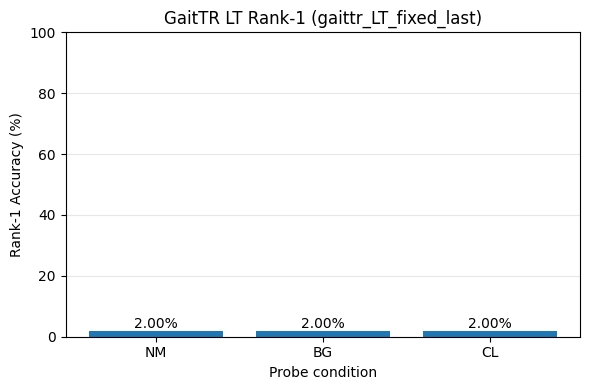

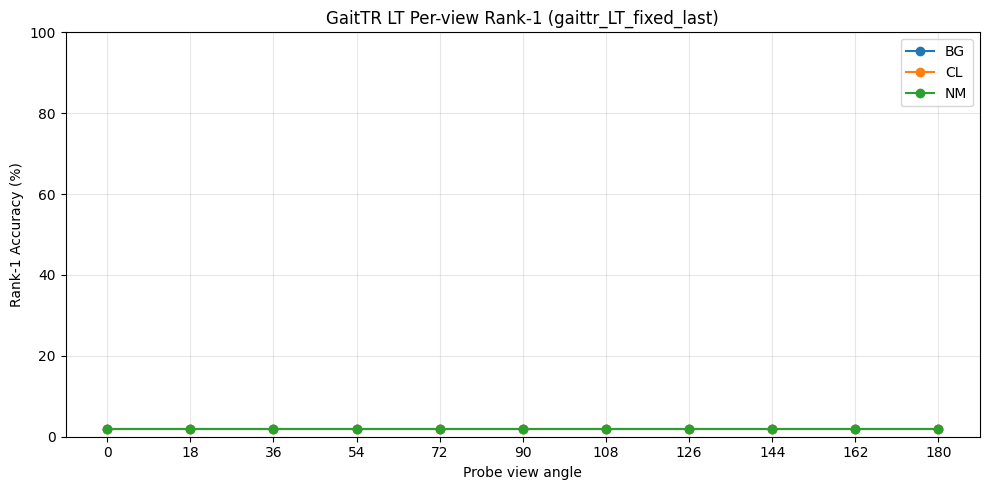

Saved plot: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/rank1_LT_gaittr_LT_fixed_last_summary_bar.png
Saved plot: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/rank1_LT_gaittr_LT_fixed_last_per_view.png


In [11]:
# ============================================================
# CELL 11 — Quick plots
# ============================================================

plt.figure(figsize=(6, 4))
plt.bar(df_summary["condition"], df_summary["rank1_percent"])
plt.ylabel("Rank-1 Accuracy (%)")
plt.xlabel("Probe condition")
plt.title(f"GaitTR {SPLIT_NAME} Rank-1 ({RUN_TAG})")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, row in df_summary.iterrows():
    plt.text(i, row["rank1_percent"] + 1, f"{row['rank1_percent']:.2f}%", ha="center")

plot_summary = RESULT_DIR / f"rank1_{SPLIT_NAME}_{RUN_TAG}_summary_bar.png"
plt.tight_layout()
plt.savefig(plot_summary, dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
for condition in sorted(df_per_view["condition"].unique()):
    sub = df_per_view[df_per_view["condition"] == condition].copy()
    sub["view_int"] = sub["view"].astype(int)
    sub = sub.sort_values("view_int")
    plt.plot(sub["view_int"], sub["rank1_percent"], marker="o", label=condition)

plt.xlabel("Probe view angle")
plt.ylabel("Rank-1 Accuracy (%)")
plt.title(f"GaitTR {SPLIT_NAME} Per-view Rank-1 ({RUN_TAG})")
plt.xticks(sorted(df_per_view["view"].astype(int).unique()))
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()

plot_per_view = RESULT_DIR / f"rank1_{SPLIT_NAME}_{RUN_TAG}_per_view.png"
plt.tight_layout()
plt.savefig(plot_per_view, dpi=150)
plt.show()

print("Saved plot:", plot_summary)
print("Saved plot:", plot_per_view)

In [12]:
# ============================================================
# CELL 12 — Failure case export
# ============================================================

df_fail = df_all_results[df_all_results["correct"] == 0].copy()
df_success = df_all_results[df_all_results["correct"] == 1].copy()

failure_tagged = RESULT_DIR / f"failure_cases_{SPLIT_NAME}_{RUN_TAG}.csv"
failure_legacy = RESULT_DIR / f"failure_cases_{SPLIT_NAME}.csv"

df_fail.to_csv(failure_tagged, index=False)
df_fail.to_csv(failure_legacy, index=False)

failure_by_view = (
    df_fail
    .groupby(["condition", "view"])
    .size()
    .reset_index(name="num_failures")
    .sort_values(["condition", "view"])
)

failure_by_view_tagged = RESULT_DIR / f"failure_by_view_{SPLIT_NAME}_{RUN_TAG}.csv"
failure_by_view_legacy = RESULT_DIR / f"failure_by_view_{SPLIT_NAME}.csv"

failure_by_view.to_csv(failure_by_view_tagged, index=False)
failure_by_view.to_csv(failure_by_view_legacy, index=False)

print("Total probes:", len(df_all_results))
print("Correct     :", len(df_success))
print("Failed      :", len(df_fail))
print("Failure CSV :", failure_tagged)

display(df_fail.head(30))
display(failure_by_view)

Total probes: 3300
Correct     : 66
Failed      : 3234
Failure CSV : /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/failure_cases_LT_gaittr_LT_fixed_last.csv


,condition,probe_index,subject,view,seq,pose_path,pred_subject,pred_view,distance,correct
22,NM,22,076,000,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,018,0.000488,0
23,NM,23,076,018,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,000,0.000488,0
24,NM,24,076,036,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,000,0.000488,0
25,NM,25,076,054,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,000,0.000488,0
26,NM,26,076,072,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,000,0.000488,0
27,NM,27,076,090,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,000,0.000488,0
28,NM,28,076,108,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,000,0.000488,0
29,NM,29,076,126,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,000,0.000488,0
30,NM,30,076,144,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,000,0.000488,0
31,NM,31,076,162,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,000,0.000488,0


,condition,view,num_failures
0,BG,000,98
1,BG,018,98
2,BG,036,98
3,BG,054,98
4,BG,072,98
5,BG,090,98
6,BG,108,98
7,BG,126,98
8,BG,144,98
9,BG,162,98


## After this notebook

If result looks reasonable, run:

```text
07_analyze_results.ipynb
```

If result is extremely low, check:

1. `embedding_diagnostics_LT.csv`
2. `rank1_LT_summary.csv`
3. checkpoint path
4. subject dtype / leading-zero issue
5. pose quality report